In [2]:
pip install --upgrade huggingface_hub fsspec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 14.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.19.0
    Uninstalling huggingface_hub-1.19.0:
      Successfully uninstalled huggingface_hub-1.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.6.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.6.0 which is incompatible.


🔄 Connecting to Hugging Face and processing 2023 data fractions...
-> Downloading and processing raw 2023 data features...
-> Sampling rows for Density and Correlation charts...
-> Aggregating monthly cloud profiles...
📊 All data structured successfully. Building your EDA Dashboard...


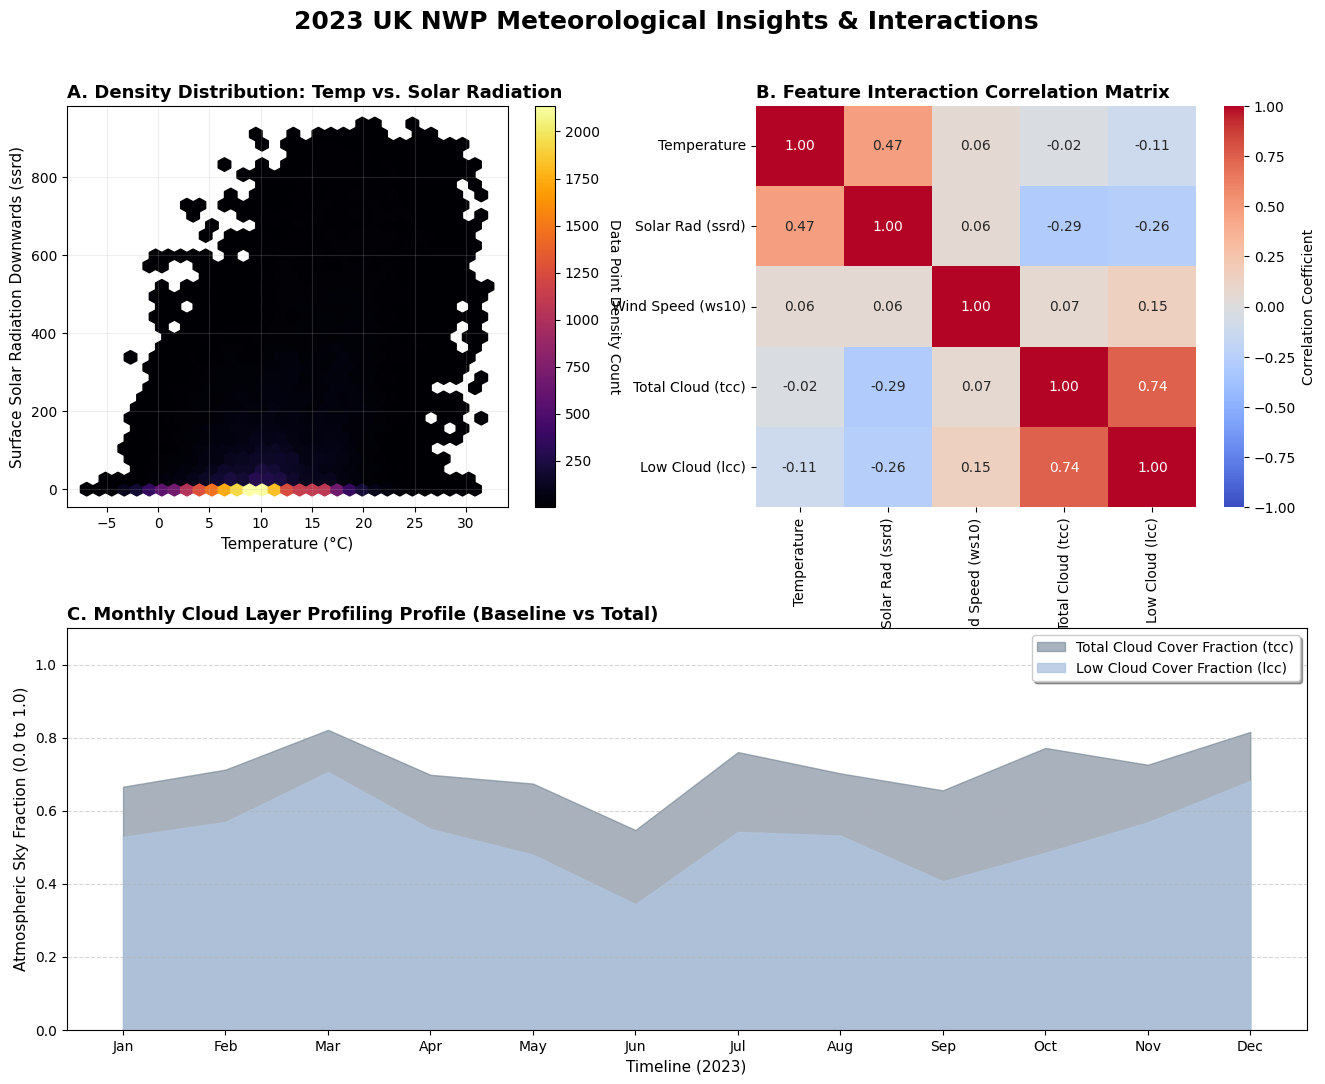


             EDA STRUCTURAL SUMMARY COMPLETE


In [1]:
import os
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETUP AND CONFIGURATION
# ==========================================
# Try Colab secret first, then env var, then fallback to getpass
try:
    from google.colab import userdata
    token = userdata.get('GRIDSIGHT_HF_TOKEN') or userdata.get('HF_TOKEN')
except ImportError:
    token = os.environ.get('GRIDSIGHT_HF_TOKEN') or os.environ.get('HF_TOKEN')

if not token:
    try:
        from getpass import getpass
        token = getpass('Enter Hugging Face Token: ')
    except Exception:
        token = ""

def resolve_hf_urls(repo_id, subfolder, token, years=None):
    from huggingface_hub import HfApi
    try:
        api = HfApi(token=token)
        repo_files = api.list_repo_tree(repo_id=repo_id, repo_type="dataset", path_in_repo=subfolder, recursive=True)
    except Exception as e:
        print(f"Error fetching directory list from Hugging Face: {e}")
        print("Please check your token or internet connection.")
        raise e
        
    file_urls = []
    for f in repo_files:
        if not f.path.endswith(".parquet"):
            continue
        
        if years is not None:
            if isinstance(years, (int, str)):
                years = [str(years)]
            else:
                years = [str(yr) for yr in years]
            if not any(f"year={yr}" in f.path or yr in f.path for yr in years):
                continue
                
        url = f"https://huggingface.co/datasets/{repo_id}/resolve/main/{f.path}"
        file_urls.append(url)
        
    return file_urls

path = "hf://datasets/gridsight-team/gridsight-bronze/met_office_nwp/year=2023/**/*.parquet"
storage_options = {
    "token": token
}

print("🔄 Connecting to Hugging Face and processing 2023 data fractions...")

# ==========================================
# 2. DATA AGGREGATION & COLLECTION
# ==========================================

print("-> Downloading and processing raw 2023 data features...")
# FIX: We collect the data first, THEN sample it safely!
try:
    df_collected = (
        pl.scan_parquet(path, storage_options=storage_options)
        .select(["valid_time", "t2m", "ssrd", "ws10", "tcc", "lcc"])
        .with_columns([
            (pl.col("t2m") - 273.15).alias("Temp_Celsius"),
            pl.col("valid_time").dt.month().alias("Month")
        ])
        .collect() # Bring it into memory safely here
    )
except Exception as e:
    print(f"Error downloading/processing 2023 data: {e}")
    raise e

print("-> Sampling rows for Density and Correlation charts...")
# Guarded sample size check
df_sample = df_collected.sample(n=min(40000, len(df_collected))).to_pandas()

print("-> Aggregating monthly cloud profiles...")
df_clouds = (
    df_collected
    .group_by("Month")
    .agg([
        pl.col("tcc").mean().alias("Total_Cloud"),
        pl.col("lcc").mean().alias("Low_Cloud")
    ])
    .sort("Month")
    .to_pandas()
)

print("📊 All data structured successfully. Building your EDA Dashboard...")

# ==========================================
# 3. DASHBOARD VISUALIZATION LAYOUT
# ==========================================
fig = plt.figure(figsize=(16, 12))
grid = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

fig.suptitle("2023 UK NWP Meteorological Insights & Interactions", fontsize=18, fontweight='bold', y=0.96)

# --- GRAPH 1: The Joint Hexbin Density Mapping (Top Left) ---
ax1 = fig.add_subplot(grid[0, 0])
hb = ax1.hexbin(df_sample['Temp_Celsius'], df_sample['ssrd'], gridsize=32, cmap='inferno', mincnt=1)
cb = fig.colorbar(hb, ax=ax1)
cb.set_label('Data Point Density Count', rotation=270, labelpad=15)
ax1.set_xlabel('Temperature (°C)', fontsize=11)
ax1.set_ylabel('Surface Solar Radiation Downwards (ssrd)', fontsize=11)
ax1.set_title('A. Density Distribution: Temp vs. Solar Radiation', fontsize=13, fontweight='bold', loc='left')
ax1.grid(True, alpha=0.2)

# --- GRAPH 2: Feature Correlation Heatmap (Top Right) ---
ax2 = fig.add_subplot(grid[0, 1])
corr_features = df_sample[['Temp_Celsius', 'ssrd', 'ws10', 'tcc', 'lcc']]
corr_features.columns = ['Temperature', 'Solar Rad (ssrd)', 'Wind Speed (ws10)', 'Total Cloud (tcc)', 'Low Cloud (lcc)']
sns.heatmap(corr_features.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=ax2, cbar_kws={'label': 'Correlation Coefficient'})
ax2.set_title('B. Feature Interaction Correlation Matrix', fontsize=13, fontweight='bold', loc='left')

# --- GRAPH 3: Monthly Cloud Cover Profiling Stacked Area (Bottom Span) ---
ax3 = fig.add_subplot(grid[1, :])
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax3.fill_between(df_clouds['Month'], df_clouds['Total_Cloud'], label='Total Cloud Cover Fraction (tcc)', color='slategrey', alpha=0.6)
ax3.fill_between(df_clouds['Month'], df_clouds['Low_Cloud'], label='Low Cloud Cover Fraction (lcc)', color='lightsteelblue', alpha=0.8)
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(month_labels)
ax3.set_ylabel('Atmospheric Sky Fraction (0.0 to 1.0)', fontsize=11)
ax3.set_xlabel('Timeline (2023)', fontsize=11)
ax3.set_ylim(0, 1.1)
ax3.set_title('C. Monthly Cloud Layer Profiling Profile (Baseline vs Total)', fontsize=13, fontweight='bold', loc='left')
ax3.legend(loc='upper right', frameon=True, shadow=True)
ax3.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

print("\n" + "="*70)
print("             EDA STRUCTURAL SUMMARY COMPLETE")
print("="*70)


In [6]:
pip install --upgrade fsspec huggingface_hub polars

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.4/833.4 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 MB 12.7 MB/s eta 0:00:00
  Attempting uninstall: polars-runtime-32
    Found existing installation: polars-runtime-32 1.35.2
    Uninstalling polars-runtime-32-1.35.2:
      Successfully uninstalled polars-runtime-32-1.35.2
  Attempting uninstall: polars
    Found existing installation: polars 1.35.2
    Uninstalling polars-1.35.2:
      Successfully uninstalled polars-1.35.2


In [2]:
import polars as pl

# 1. Base path configuration
path = "hf://datasets/gridsight-team/gridsight-bronze/met_office_nwp/year=2024/**/*.parquet"
storage_options = {"token": token}

# 2. Scan the file metadata
try:
    lf = pl.scan_parquet(path, storage_options=storage_options)
    # Get column names and types
    col_names = lf.columns
    col_count = len(col_names)
    schema_details = lf.schema
except Exception as e:
    print(f"Error scanning parquet metadata: {e}")
    raise e

print("=" * 60)
print(f"📊 DATASET COLUMN OVERVIEW FOR 2024")
print("=" * 60)
print(f"Total Number of Columns: {col_count}\n")
print("List of Column Names:")
print(col_names)
print("\nDetailed Column Data Types (Schema):")
print(schema_details)
print("=" * 60)


/tmp/ipykernel_2200/1426831597.py:11: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  col_names = lf.columns


📊 DATASET COLUMN OVERVIEW FOR 2024
Total Number of Columns: 13

List of Column Names:
['init_time', 'valid_time', 'forecast_hour', 'region', 'lat', 'lon', 'ssrd', 'tcc', 'lcc', 't2m', 'ws10', 'source_file', 'extracted_at']

Detailed Column Data Types (Schema):
Schema({'init_time': Datetime(time_unit='us', time_zone='UTC'), 'valid_time': Datetime(time_unit='us', time_zone='UTC'), 'forecast_hour': Int64, 'region': String, 'lat': Float64, 'lon': Float64, 'ssrd': Float64, 'tcc': Float64, 'lcc': Float64, 't2m': Float64, 'ws10': Float64, 'source_file': String, 'extracted_at': String})


/tmp/ipykernel_2200/1426831597.py:13: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  schema_details = lf.schema


In [3]:
import polars as pl

# Setup path and Hugging Face token
path = "hf://datasets/gridsight-team/gridsight-bronze/met_office_nwp/year=2024/**/*.parquet"
storage_options = {"token": token}

print("🔄 Fetching live data rows from the server...")

# Fetch, clean, and collect a 5-row look at the real data points
try:
    df_output_preview = (
        pl.scan_parquet(path, storage_options=storage_options)
        .select([
            "valid_time",
            "region",
            "forecast_hour",
            "t2m",
            "ssrd",
            "ws10",
            "tcc"
        ])
        # Convert temperature from Kelvin to Celsius for better readability
        .with_columns([
            (pl.col("t2m") - 273.15).round(2).alias("Temp_Celsius"),
            pl.col("ssrd").round(2),
            pl.col("ws10").round(2)
        ])
        # Drop the original raw Kelvin column to keep the screen neat
        .drop("t2m")
        .head(5)
        .collect()
    )
except Exception as e:
    print(f"Error fetching datastream preview: {e}")
    raise e

print("\n" + "="*85)
print("                       LIVE MET OFFICE NWP DATASTREAM OUTPUT")
print("="*85)
print(df_output_preview)
print("="*85)


🔄 Fetching live data rows from the server...

                       LIVE MET OFFICE NWP DATASTREAM OUTPUT
shape: (5, 7)
┌─────────────────────────┬─────────────┬───────────────┬──────┬──────┬───────────┬──────────────┐
│ valid_time              ┆ region      ┆ forecast_hour ┆ ssrd ┆ ws10 ┆ tcc       ┆ Temp_Celsius │
│ ---                     ┆ ---         ┆ ---           ┆ ---  ┆ ---  ┆ ---       ┆ ---          │
│ datetime[μs, UTC]       ┆ str         ┆ i64           ┆ f64  ┆ f64  ┆ f64       ┆ f64          │
╞═════════════════════════╪═════════════╪═══════════════╪══════╪══════╪═══════════╪══════════════╡
│ 2024-01-01 00:00:00 UTC ┆ East_Anglia ┆ 0             ┆ 0.0  ┆ 6.69 ┆ 1.0       ┆ 7.74         │
│ 2024-01-01 00:00:00 UTC ┆ London      ┆ 0             ┆ 0.0  ┆ 6.94 ┆ 0.7578125 ┆ 8.67         │
│ 2024-01-01 00:00:00 UTC ┆ Midlands    ┆ 0             ┆ 0.0  ┆ 7.0  ┆ 0.125     ┆ 6.93         │
│ 2024-01-01 00:00:00 UTC ┆ North       ┆ 0             ┆ 0.0  ┆ 5.12 ┆ 1.0       ┆ 5.7

🔄 Connecting to Hugging Face and fetching 2024 data...
-> Extracting statistical subsets...
📊 Building your 2024 EDA Dashboard...


/tmp/ipykernel_2200/1634179511.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample_2024.sort_values('region'), x='region', y='Temp_Celsius', ax=ax3, palette='coolwarm')


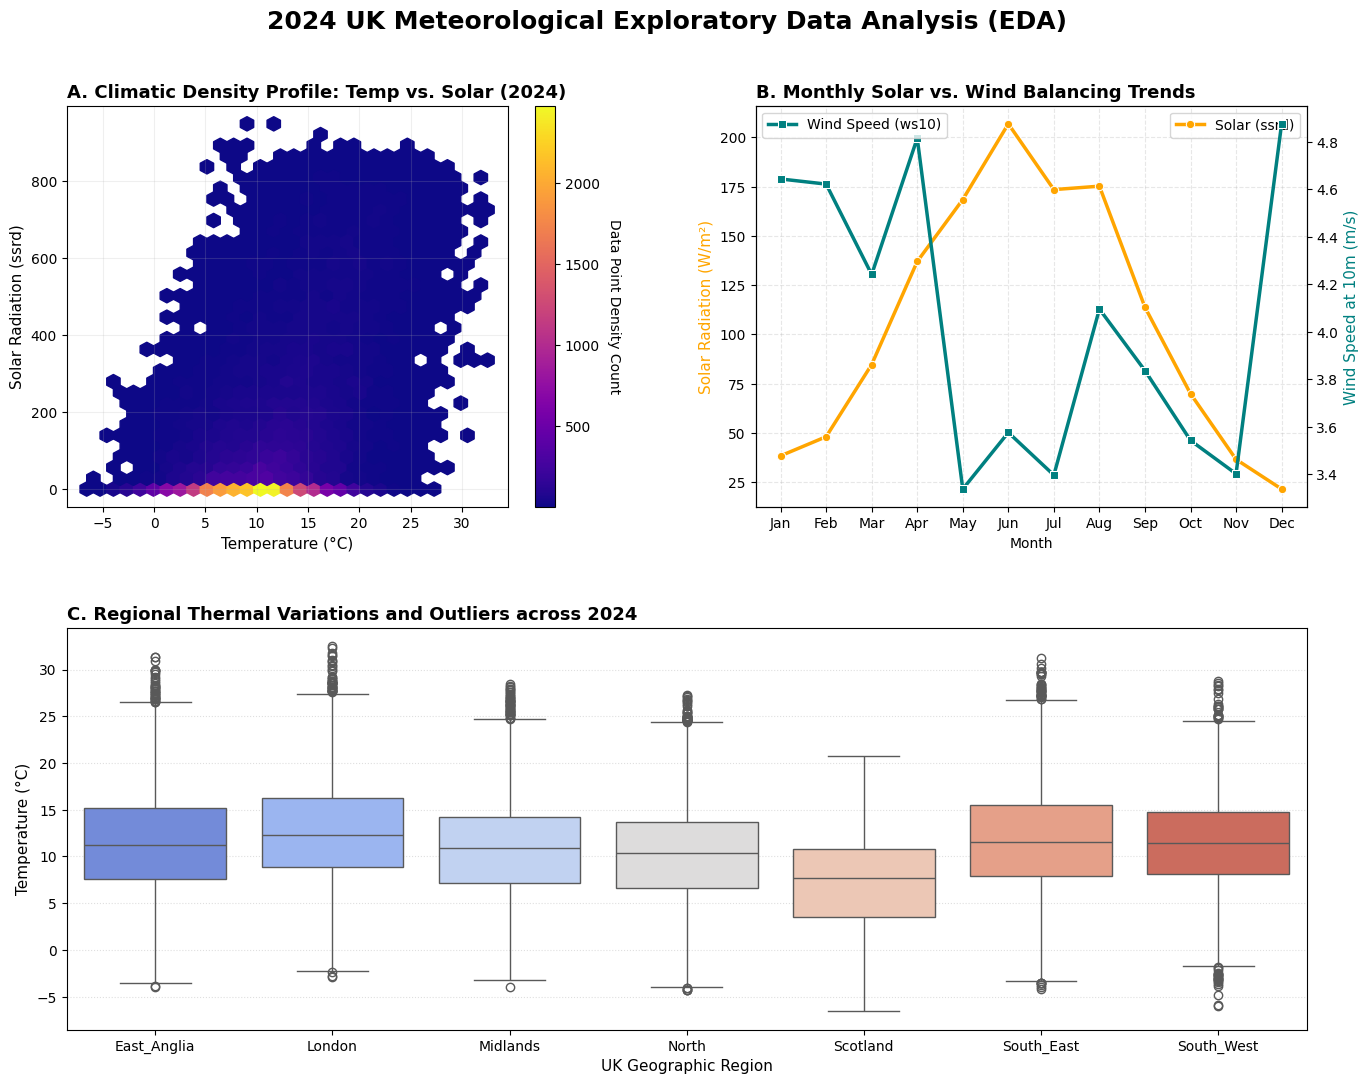


             2024 EDA COMPLETED SUCCESSFULLY


In [4]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETUP AND CONFIGURATION
# ==========================================
# Target the year 2024 partition directly
path = "hf://datasets/gridsight-team/gridsight-bronze/met_office_nwp/year=2024/**/*.parquet"
storage_options = {"token": token}

print("🔄 Connecting to Hugging Face and fetching 2024 data...")

# ==========================================
# 2. OPTIMIZED DATA PROCESSING PIPELINE
# ==========================================
# Download core columns and pre-calculate metrics
try:
    df_collected_2024 = (
        pl.scan_parquet(path, storage_options=storage_options)
        .select(["valid_time", "region", "ssrd", "ws10", "tcc", "t2m"])
        .with_columns([
            (pl.col("t2m") - 273.15).alias("Temp_Celsius"),
            pl.col("valid_time").dt.month().alias("Month")
        ])
        .collect()
    )
except Exception as e:
    print(f"Error fetching 2024 data: {e}")
    raise e

print("-> Extracting statistical subsets...")
# Guarded sample size check
df_sample_2024 = df_collected_2024.sample(n=min(40000, len(df_collected_2024))).to_pandas()

# Aggregate monthly trends for regional comparisons
df_monthly_2024 = (
    df_collected_2024
    .group_by("Month")
    .agg([
        pl.col("Temp_Celsius").mean().alias("Avg_Temp"),
        pl.col("ssrd").mean().alias("Avg_Solar"),
        pl.col("ws10").mean().alias("Avg_Wind")
    ])
    .sort("Month")
    .to_pandas()
)

print("📊 Building your 2024 EDA Dashboard...")

# ==========================================
# 3. ADVANCED VISUALIZATION PLOTS
# ==========================================
fig = plt.figure(figsize=(16, 12))
grid = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

fig.suptitle("2024 UK Meteorological Exploratory Data Analysis (EDA)", fontsize=18, fontweight='bold', y=0.96)
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# --- PLOT 1: Hexbin Temperature vs. Solar Density (Top Left) ---
ax1 = fig.add_subplot(grid[0, 0])
hb = ax1.hexbin(df_sample_2024['Temp_Celsius'], df_sample_2024['ssrd'], gridsize=30, cmap='plasma', mincnt=1)
cb = fig.colorbar(hb, ax=ax1)
cb.set_label('Data Point Density Count', rotation=270, labelpad=15)
ax1.set_xlabel('Temperature (°C)', fontsize=11)
ax1.set_ylabel('Solar Radiation (ssrd)', fontsize=11)
ax1.set_title('A. Climatic Density Profile: Temp vs. Solar (2024)', fontsize=13, fontweight='bold', loc='left')
ax1.grid(True, alpha=0.2)

# --- PLOT 2: Renewable Energy Complementary Timeline (Top Right) ---
ax2 = fig.add_subplot(grid[0, 1])
ax2_twin = ax2.twinx()
# Plot Solar Line
sns.lineplot(data=df_monthly_2024, x='Month', y='Avg_Solar', color='orange', marker='o', linewidth=2.5, ax=ax2, label='Solar (ssrd)')
# Plot Wind Line
sns.lineplot(data=df_monthly_2024, x='Month', y='Avg_Wind', color='teal', marker='s', linewidth=2.5, ax=ax2_twin, label='Wind Speed (ws10)')

ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_labels)
ax2.set_ylabel('Solar Radiation (W/m²)', color='orange', fontsize=11)
ax2_twin.set_ylabel('Wind Speed at 10m (m/s)', color='teal', fontsize=11)
ax2.set_title('B. Monthly Solar vs. Wind Balancing Trends', fontsize=13, fontweight='bold', loc='left')
ax2.grid(True, alpha=0.3, linestyle='--')

# --- PLOT 3: Regional Temperature Distributions (Bottom Span) ---
ax3 = fig.add_subplot(grid[1, :])
# Sort regions so the plot looks orderly
sns.boxplot(data=df_sample_2024.sort_values('region'), x='region', y='Temp_Celsius', ax=ax3, palette='coolwarm')
ax3.set_xlabel('UK Geographic Region', fontsize=11)
ax3.set_ylabel('Temperature (°C)', fontsize=11)
ax3.set_title('C. Regional Thermal Variations and Outliers across 2024', fontsize=13, fontweight='bold', loc='left')
ax3.grid(axis='y', alpha=0.4, linestyle=':')

plt.show()

print("\n" + "="*70)
print("             2024 EDA COMPLETED SUCCESSFULLY")
print("="*70)


In [7]:
import polars as pl

path = "hf://datasets/gridsight-team/gridsight-bronze/neso/**/*.parquet"

storage_options = {
    "token": token
}

try:
    df = pl.scan_parquet(path, storage_options=storage_options)
    df_test = df.collect().to_pandas()
except Exception as e:
    print(f"Error loading NESO dataset: {e}")
    raise e

print("Done")


Done


In [8]:
# 1. Render the data as a clean, interactive table (just run this as the last line of a cell)
df_test.head(5)

# 2. See information about missing (null) values and memory usage
print(df_test.info())

# 3. See all column names as a list
print(df_test.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886126 entries, 0 to 10886125
Data columns (total 11 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   DATE_GMT                 datetime64[ms]
 1   TIME_GMT                 object        
 2   SETTLEMENT_DATE          datetime64[ms]
 3   SETTLEMENT_PERIOD        int64         
 4   EMBEDDED_WIND_FORECAST   int64         
 5   EMBEDDED_WIND_CAPACITY   int64         
 6   EMBEDDED_SOLAR_FORECAST  int64         
 7   EMBEDDED_SOLAR_CAPACITY  int64         
 8   fetched_at               object        
 9   source_url               object        
 10  resource_id              object        
dtypes: datetime64[ms](2), int64(5), object(4)
memory usage: 913.6+ MB
None
['DATE_GMT', 'TIME_GMT', 'SETTLEMENT_DATE', 'SETTLEMENT_PERIOD', 'EMBEDDED_WIND_FORECAST', 'EMBEDDED_WIND_CAPACITY', 'EMBEDDED_SOLAR_FORECAST', 'EMBEDDED_SOLAR_CAPACITY', 'fetched_at', 'source_url', 'resource_id']


--- STEP 1: Reading Parquet File with Polars ---
Dataset successfully loaded and filtered for 2023!
Rows: 5336880, Columns: 11

--- STEP 2: Automatic Type Identification ---
Numeric metrics ready for EDA evaluation: ['SETTLEMENT_PERIOD', 'EMBEDDED_WIND_FORECAST', 'EMBEDDED_WIND_CAPACITY', 'EMBEDDED_SOLAR_FORECAST', 'EMBEDDED_SOLAR_CAPACITY']

--- STEP 3: Summary Description ---
shape: (9, 6)
┌────────────┬─────────────────┬────────────────┬────────────────┬────────────────┬────────────────┐
│ statistic  ┆ SETTLEMENT_PERI ┆ EMBEDDED_WIND_ ┆ EMBEDDED_WIND_ ┆ EMBEDDED_SOLAR ┆ EMBEDDED_SOLAR │
│ ---        ┆ OD              ┆ FORECAST       ┆ CAPACITY       ┆ _FORECAST      ┆ _CAPACITY      │
│ str        ┆ ---             ┆ ---            ┆ ---            ┆ ---            ┆ ---            │
│            ┆ f64             ┆ f64            ┆ f64            ┆ f64            ┆ f64            │
╞════════════╪═════════════════╪════════════════╪════════════════╪════════════════╪════════════════╡

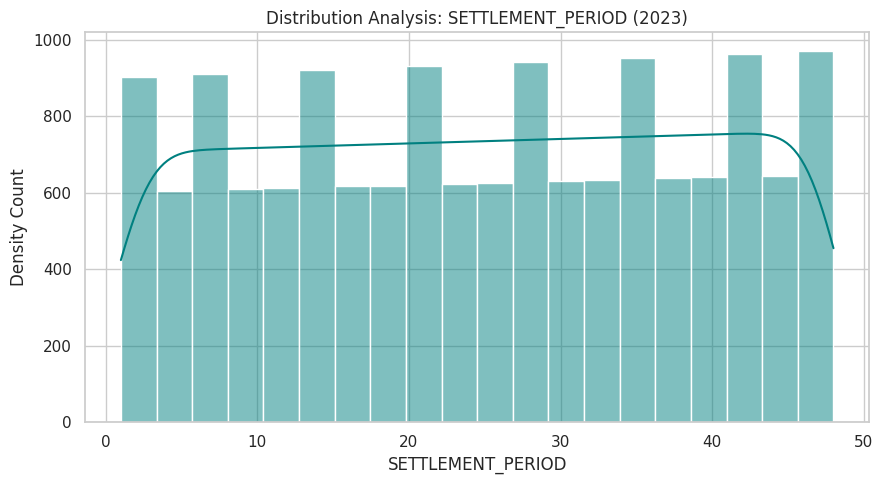


--- STEP 5: Creating Correlation Matrix Heatmap ---


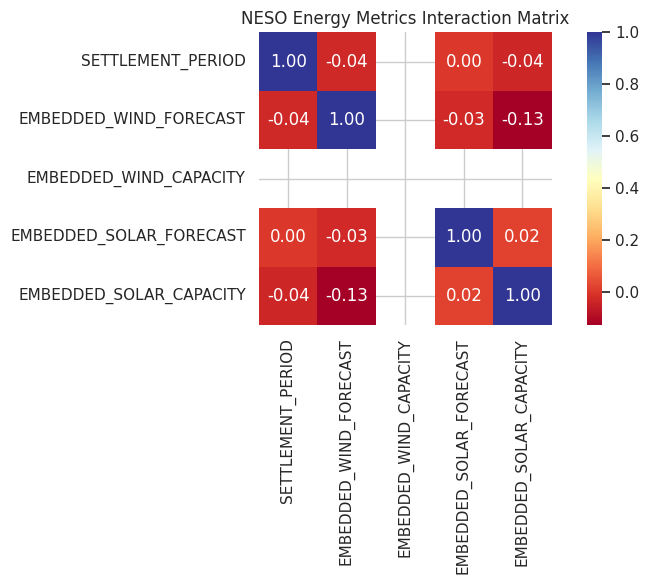


EDA Execution Loop Complete!


In [21]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual layout style
sns.set_theme(style="whitegrid")

print("--- STEP 1: Reading Parquet File with Polars ---")

# Reuse df_test which was already loaded in a previous cell (wE0tSydzexy-)
# df_test is a pandas DataFrame, convert it to polars for the rest of the pipeline
df_polars = pl.from_pandas(df_test)

# Filter for year 2023 as intended by the original file_path
# Assuming 'DATE_GMT' is present and can be used to filter the year
# Make sure 'DATE_GMT' is a date/datetime type in Polars
df_polars = df_polars.with_columns(
    pl.col("DATE_GMT").cast(pl.Date, strict=False)
)
df_polars = df_polars.filter(pl.col("DATE_GMT").dt.year() == 2023)


print(f"Dataset successfully loaded and filtered for 2023!")
print(f"Rows: {df_polars.shape[0]}, Columns: {df_polars.shape[1]}")

print("\n--- STEP 2: Automatic Type Identification ---")
# Polars automatically separates true float/integer numeric values from strings
all_numeric_cols = [
    col for col, dtype in zip(df_polars.columns, df_polars.dtypes)
    if dtype in [pl.Float64, pl.Float32, pl.Int64, pl.Int32]
]

# If Polars read columns as strings, forcefully parse them out to numbers safely
fallback_cols = ['EMBEDDED_WIND_FORECAST', 'EMBEDDED_SOLAR_FORECAST', 'EMBEDDED_WIND_CAPACITY', 'EMBEDDED_SOLAR_CAPACITY']
for col in fallback_cols:
    if col in df_polars.columns and col not in all_numeric_cols:
        try:
            df_polars = df_polars.with_columns(pl.col(col).cast(pl.Float64, strict=False))
            # After successful cast, ensure it's added to all_numeric_cols if it wasn't already
            if col not in all_numeric_cols:
                all_numeric_cols.append(col)
            print(f"Force-converted column to numeric: {col}")
        except Exception:
            pass
# Filter all_numeric_cols to contain only columns that actually exist in df_polars
all_numeric_cols = [col for col in all_numeric_cols if col in df_polars.columns]

print(f"Numeric metrics ready for EDA evaluation: {all_numeric_cols}")

print("\n--- STEP 3: Summary Description ---")
# Calculate high-performance descriptive summaries via Polars
# Only select columns that are actually present in the DataFrame
present_numeric_cols = [col for col in all_numeric_cols if col in df_polars.columns]
if present_numeric_cols:
    print(df_polars.select(present_numeric_cols).describe())
else:
    print("No numeric columns available for description.")


print("\n--- STEP 4: Creating a Distribution Graph ---")
if len(present_numeric_cols) > 0:
    # Use the first available clean metric column found
    target_plot_col = present_numeric_cols[0]

    # Grab a tiny 15,000 row sample to feed into Seaborn quickly
    plot_sample = df_polars.select(target_plot_col).drop_nulls().head(15000).to_pandas()

    plt.figure(figsize=(9, 5))
    sns.histplot(data=plot_sample, x=target_plot_col, bins=20, kde=True, color='teal')
    plt.title(f'Distribution Analysis: {target_plot_col} (2023)')
    plt.xlabel(target_plot_col)
    plt.ylabel('Density Count')
    plt.tight_layout()
    plt.show()
else:
    print("Could not find any available numeric column arrays to construct distribution plot.")

print("\n--- STEP 5: Creating Correlation Matrix Heatmap ---")
if len(present_numeric_cols) > 1:
    # Convert only the essential numerical metrics to pandas dataframe for correlation modeling
    matrix_sample = df_polars.select(present_numeric_cols).drop_nulls().head(30000).to_pandas()
    correlation_data = matrix_sample.corr()

    plt.figure(figsize=(9, 6))
    sns.heatmap(correlation_data, annot=True, cmap='RdYlBu', fmt=".2f", square=True, cbar=True)
    plt.title('NESO Energy Metrics Interaction Matrix')
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient correlation dimensions available to project heatmap.")

print("\nEDA Execution Loop Complete!")

--- STEP 1: Loading `embedded_solar_and_wind_forecast_archive_2024.parquet` ---
Data loaded successfully from local file!
Rows: 5451115, Columns: 12

Converting energy forecasting columns to numeric types...
Numeric metrics ready for EDA evaluation: ['SETTLEMENT_PERIOD', 'EMBEDDED_WIND_FORECAST', 'EMBEDDED_WIND_CAPACITY', 'EMBEDDED_SOLAR_FORECAST', 'EMBEDDED_SOLAR_CAPACITY']

=== Dataset Dimensions (Rows, Columns) ===
(5451115, 12)

=== Data Column Types ===
[Datetime(time_unit='ms', time_zone='UTC'), Time, Datetime(time_unit='ms', time_zone='UTC'), Int64, Int64, Int64, Int64, Int64, Datetime(time_unit='ms', time_zone='UTC'), String, String, String]

=== Summary Statistics ===
shape: (9, 6)
┌────────────┬─────────────────┬────────────────┬────────────────┬────────────────┬────────────────┐
│ statistic  ┆ SETTLEMENT_PERI ┆ EMBEDDED_WIND_ ┆ EMBEDDED_WIND_ ┆ EMBEDDED_SOLAR ┆ EMBEDDED_SOLAR │
│ ---        ┆ OD              ┆ FORECAST       ┆ CAPACITY       ┆ _FORECAST      ┆ _CAPACITY     

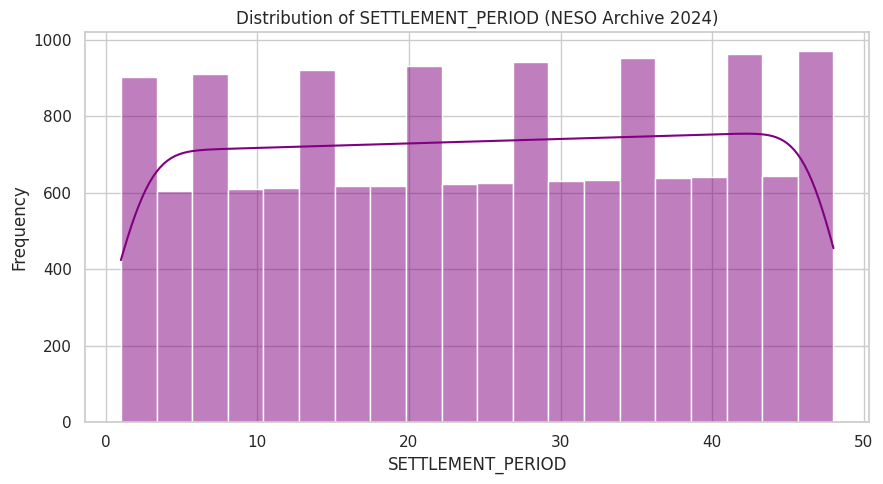


Generating Correlation Heatmap...


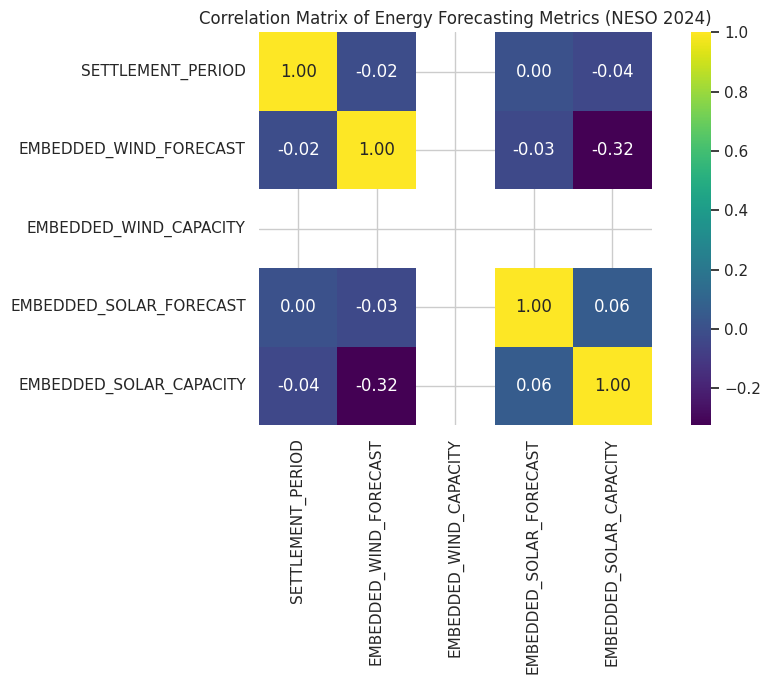


EDA Pipeline Finished Successfully for embedded_solar_and_wind_forecast_archive_2024.parquet!


In [23]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for plots
sns.set_theme(style="whitegrid")

print("--- STEP 1: Loading `embedded_solar_and_wind_forecast_archive_2024.parquet` ---")

# User provided local file path
file_path_2024 = "/content/embedded_solar_and_wind_forecast_archive_2024.parquet"

# Scan the lazy frame, telling Polars to ignore unexpected schema anomalies
lazy_df_2024 = pl.scan_parquet(file_path_2024, extra_columns="ignore")

# Collect into memory
df_polars_local_2024 = lazy_df_2024.collect()
print("Data loaded successfully from local file!")

print(f"Rows: {df_polars_local_2024.shape[0]}, Columns: {df_polars_local_2024.shape[1]}")

# =====================================================================
# STEP 2: Convert Key Object Columns to Numeric Types
# =====================================================================
print("\nConverting energy forecasting columns to numeric types...")
columns_to_convert_local = [
    'EMBEDDED_WIND_FORECAST',
    'EMBEDDED_WIND_CAPACITY',
    'EMBEDDED_SOLAR_FORECAST',
    'EMBEDDED_SOLAR_CAPACITY'
]

# Polars automatically separates true float/integer numeric values from strings
all_numeric_cols_local = [
    col for col, dtype in zip(df_polars_local_2024.columns, df_polars_local_2024.dtypes)
    if dtype in [pl.Float64, pl.Float32, pl.Int64, pl.Int32, pl.UInt64, pl.UInt32]
]

for col in columns_to_convert_local:
    if col in df_polars_local_2024.columns and col not in all_numeric_cols_local:
        try:
            df_polars_local_2024 = df_polars_local_2024.with_columns(pl.col(col).cast(pl.Float64, strict=False))
            if col not in all_numeric_cols_local:
                all_numeric_cols_local.append(col)
            print(f"Force-converted column to numeric: {col}")
        except Exception:
            pass

# Filter all_numeric_cols_local to contain only columns that actually exist in df_polars_local_2024
all_numeric_cols_local = [col for col in all_numeric_cols_local if col in df_polars_local_2024.columns]

print(f"Numeric metrics ready for EDA evaluation: {all_numeric_cols_local}")

# =====================================================================
# STEP 3: Structural Overview and Summary Statistics
# =====================================================================
print("\n=== Dataset Dimensions (Rows, Columns) ===")
print(df_polars_local_2024.shape)

print("\n=== Data Column Types ===")
print(df_polars_local_2024.dtypes)

print("\n=== Summary Statistics ===")
# Only select columns that are actually present in the DataFrame
present_numeric_cols_local = [col for col in all_numeric_cols_local if col in df_polars_local_2024.columns]
if present_numeric_cols_local:
    print(df_polars_local_2024.select(present_numeric_cols_local).describe())
else:
    print("No numeric columns available for description.")


# =====================================================================
# STEP 4: Check for Missing Data
# =====================================================================
print("\n=== Missing Values Count Per Column ===")
# Polars equivalent to isnull().sum()
missing_counts_polars = df_polars_local_2024.null_count()
# Convert to pandas Series for easy printing of non-zero counts
missing_counts_pd = missing_counts_polars.to_pandas().iloc[0]
print(missing_counts_pd[missing_counts_pd > 0] if missing_counts_pd.sum() > 0 else "No missing values found!")


# =====================================================================
# STEP 5: Visualizing Distributions (Histogram)
# =====================================================================
if len(present_numeric_cols_local) > 0:
    # Use the first available clean metric column found
    target_plot_col = present_numeric_cols_local[0]
    print(f"\nVisualizing distribution for: {target_plot_col}")

    plt.figure(figsize=(9, 5))
    # Grab a tiny 15,000 row sample to feed into Seaborn quickly
    # Ensure only the target column is selected and nulls are dropped before converting to pandas
    subset_data = df_polars_local_2024.select(target_plot_col).drop_nulls().head(15000).to_pandas()

    sns.histplot(data=subset_data, x=target_plot_col, bins=20, kde=True, color='purple')
    plt.title(f'Distribution of {target_plot_col} (NESO Archive 2024)')
    plt.xlabel(target_plot_col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
else:
    print("\nNo numeric columns available to plot a distribution.")


# =====================================================================
# STEP 6: Feature Correlations (Heatmap)
# =====================================================================
if len(present_numeric_cols_local) > 1:
    print("\nGenerating Correlation Heatmap...")
    plt.figure(figsize=(10, 7))

    # Convert only the essential numerical metrics to pandas dataframe for correlation modeling
    # Take a sample for performance if the DataFrame is very large
    matrix_sample = df_polars_local_2024.select(present_numeric_cols_local).drop_nulls().head(30000).to_pandas()
    correlation_data = matrix_sample.corr()

    sns.heatmap(correlation_data, annot=True, cmap='viridis', fmt=".2f", square=True, cbar=True)
    plt.title('Correlation Matrix of Energy Forecasting Metrics (NESO 2024)')
    plt.tight_layout()
    plt.show()
else:
    print("\nNot enough unique numerical columns available to map correlation vectors.")

print("\nEDA Pipeline Finished Successfully for embedded_solar_and_wind_forecast_archive_2024.parquet!")

In [24]:
import polars as pl

path = "hf://datasets/gridsight-team/gridsight-silver/silver_met_office_nwp/**/*.parquet"

storage_options = {
    "token": token
}

try:
    df = pl.scan_parquet(
        path,
        storage_options=storage_options
    ).collect()
    df_test = df.to_pandas()
except Exception as e:
    print(f"Error scanning Silver Met Office: {e}")
    raise e

print("Done")
print(df_test.head())


Done
              timestamp_utc  ssrd_uk    tcc_uk    lcc_uk      t2m_uk  \
0 2023-01-01 00:00:00+00:00      0.0  0.943984  0.763281  282.649536   
1 2023-01-01 00:30:00+00:00      0.0  0.943984  0.763281  282.649536   
2 2023-01-01 01:00:00+00:00      0.0  0.960156  0.629922  282.381866   
3 2023-01-01 01:30:00+00:00      0.0  0.960156  0.629922  282.381866   
4 2023-01-01 02:00:00+00:00      0.0  0.966719  0.471406  282.330933   

    ws10_uk                 init_time  nwp_age_h data_quality_flag  
0  6.210625 2023-01-01 00:00:00+00:00        0.0                ok  
1  6.210625 2023-01-01 00:00:00+00:00        0.0                ok  
2  6.828125 2023-01-01 00:00:00+00:00        1.0                ok  
3  6.828125 2023-01-01 00:00:00+00:00        1.0                ok  
4  6.997500 2023-01-01 00:00:00+00:00        2.0                ok  


In [30]:
import polars as pl
import pandas as pd

path = "hf://datasets/gridsight-team/gridsight-silver/silver_met_office_nwp/**/*.parquet"

storage_options = {
    "token": token
}

print("--- Step 1: Scanning and Filtering for 2023 Only ---")
try:
    # 1. Scan the remote dataset lazily
    lazy_df = pl.scan_parquet(path, storage_options=storage_options)

    # 2. Filter for 2023 entries using the 'timestamp_utc' column before collecting it
    lazy_df_2023 = lazy_df.filter(pl.col("timestamp_utc").dt.year() == 2023)

    # 3. Collect only the 2023 rows into memory and convert to Pandas
    df_2023 = lazy_df_2023.collect().to_pandas()
except Exception as e:
    print(f"Error loading 2023 Silver data: {e}")
    raise e

print("Successfully loaded 2023 data!")

# =====================================================================
# STEP 2: ANALYZE WHAT IS INSIDE THE 2023 DATA
# =====================================================================
print("\n=== 2023 Dataset Shape (Rows, Columns) ===")
print(df_2023.shape)

print("\n=== Column Names and Data Types for 2023 ===")
print(df_2023.dtypes)

print("\n=== First 5 Rows Preview ===")
print(df_2023.head())

print("\n=== Missing Data in 2023 ===")
missing_2023 = df_2023.isnull().sum()
print(missing_2023[missing_2023 > 0] if missing_2023.sum() > 0 else "No missing rows!")


--- Step 1: Scanning and Filtering for 2023 Only ---
Successfully loaded 2023 data!

=== 2023 Dataset Shape (Rows, Columns) ===
(17520, 9)

=== Column Names and Data Types for 2023 ===
timestamp_utc        datetime64[us, UTC]
ssrd_uk                          float32
tcc_uk                           float32
lcc_uk                           float32
t2m_uk                           float32
ws10_uk                          float32
init_time            datetime64[us, UTC]
nwp_age_h                        float32
data_quality_flag                 object
dtype: object

=== First 5 Rows Preview ===
              timestamp_utc  ssrd_uk    tcc_uk    lcc_uk      t2m_uk  \
0 2023-01-01 00:00:00+00:00      0.0  0.943984  0.763281  282.649536   
1 2023-01-01 00:30:00+00:00      0.0  0.943984  0.763281  282.649536   
2 2023-01-01 01:00:00+00:00      0.0  0.960156  0.629922  282.381866   
3 2023-01-01 01:30:00+00:00      0.0  0.960156  0.629922  282.381866   
4 2023-01-01 02:00:00+00:00      0.0  0.96

### **2023 Met Office NWP Data: Daily Trends of Key Meteorological Variables**

This section visualizes the daily average trends for temperature, solar radiation, and wind speed throughout 2023. This helps in understanding the seasonal variations and overall patterns of these critical weather parameters.

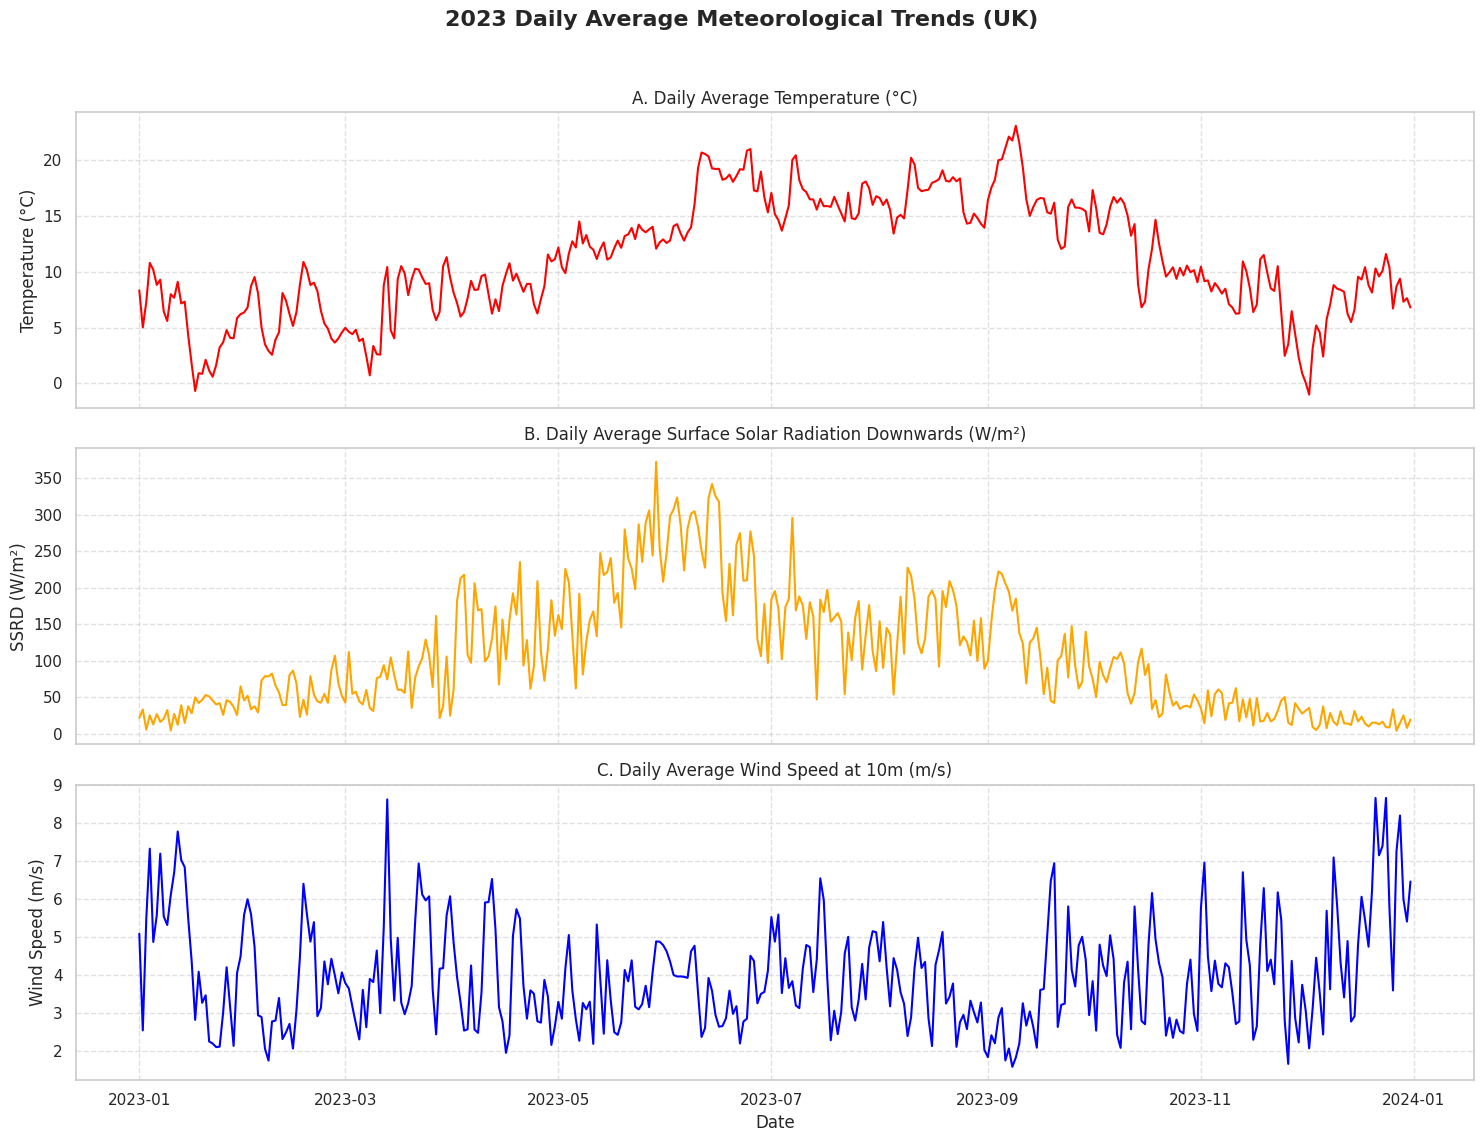

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'timestamp_utc' is a datetime object
df_2023['timestamp_utc'] = pd.to_datetime(df_2023['timestamp_utc'])

# Calculate daily averages for relevant features
daily_avg_df_2023 = df_2023.groupby(df_2023['timestamp_utc'].dt.date).agg({
    't2m_uk': 'mean',  # Temperature in Kelvin
    'ssrd_uk': 'mean', # Surface Solar Radiation Downwards
    'ws10_uk': 'mean'  # Wind speed at 10m
}).reset_index()

# Convert temperature from Kelvin to Celsius for better readability
daily_avg_df_2023['t2m_celsius'] = daily_avg_df_2023['t2m_uk'] - 273.15

# Plotting the daily trends
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
fig.suptitle('2023 Daily Average Meteorological Trends (UK)', fontsize=16, fontweight='bold')

# Daily Average Temperature
sns.lineplot(x='timestamp_utc', y='t2m_celsius', data=daily_avg_df_2023, ax=axes[0], color='red')
axes[0].set_title('A. Daily Average Temperature (°C)')
axes[0].set_ylabel('Temperature (°C)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Daily Average Solar Radiation
sns.lineplot(x='timestamp_utc', y='ssrd_uk', data=daily_avg_df_2023, ax=axes[1], color='orange')
axes[1].set_title('B. Daily Average Surface Solar Radiation Downwards (W/m²)')
axes[1].set_ylabel('SSRD (W/m²)')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Daily Average Wind Speed
sns.lineplot(x='timestamp_utc', y='ws10_uk', data=daily_avg_df_2023, ax=axes[2], color='blue')
axes[2].set_title('C. Daily Average Wind Speed at 10m (m/s)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Wind Speed (m/s)')
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap
plt.show()


### **2023 Advanced EDA: Seasonality and Feature Interactions**

Having explored 2024 and the start of 2025, we now look back at the full **2023** dataset to understand its specific characteristics:
1. **Renewable Complementarity**: Observing the seasonal handover between solar and wind energy.
2. **Thermal Density**: Analyzing the annual temperature profile for the UK.
3. **Atmospheric Interactions**: Correlation between cloud cover and solar output.

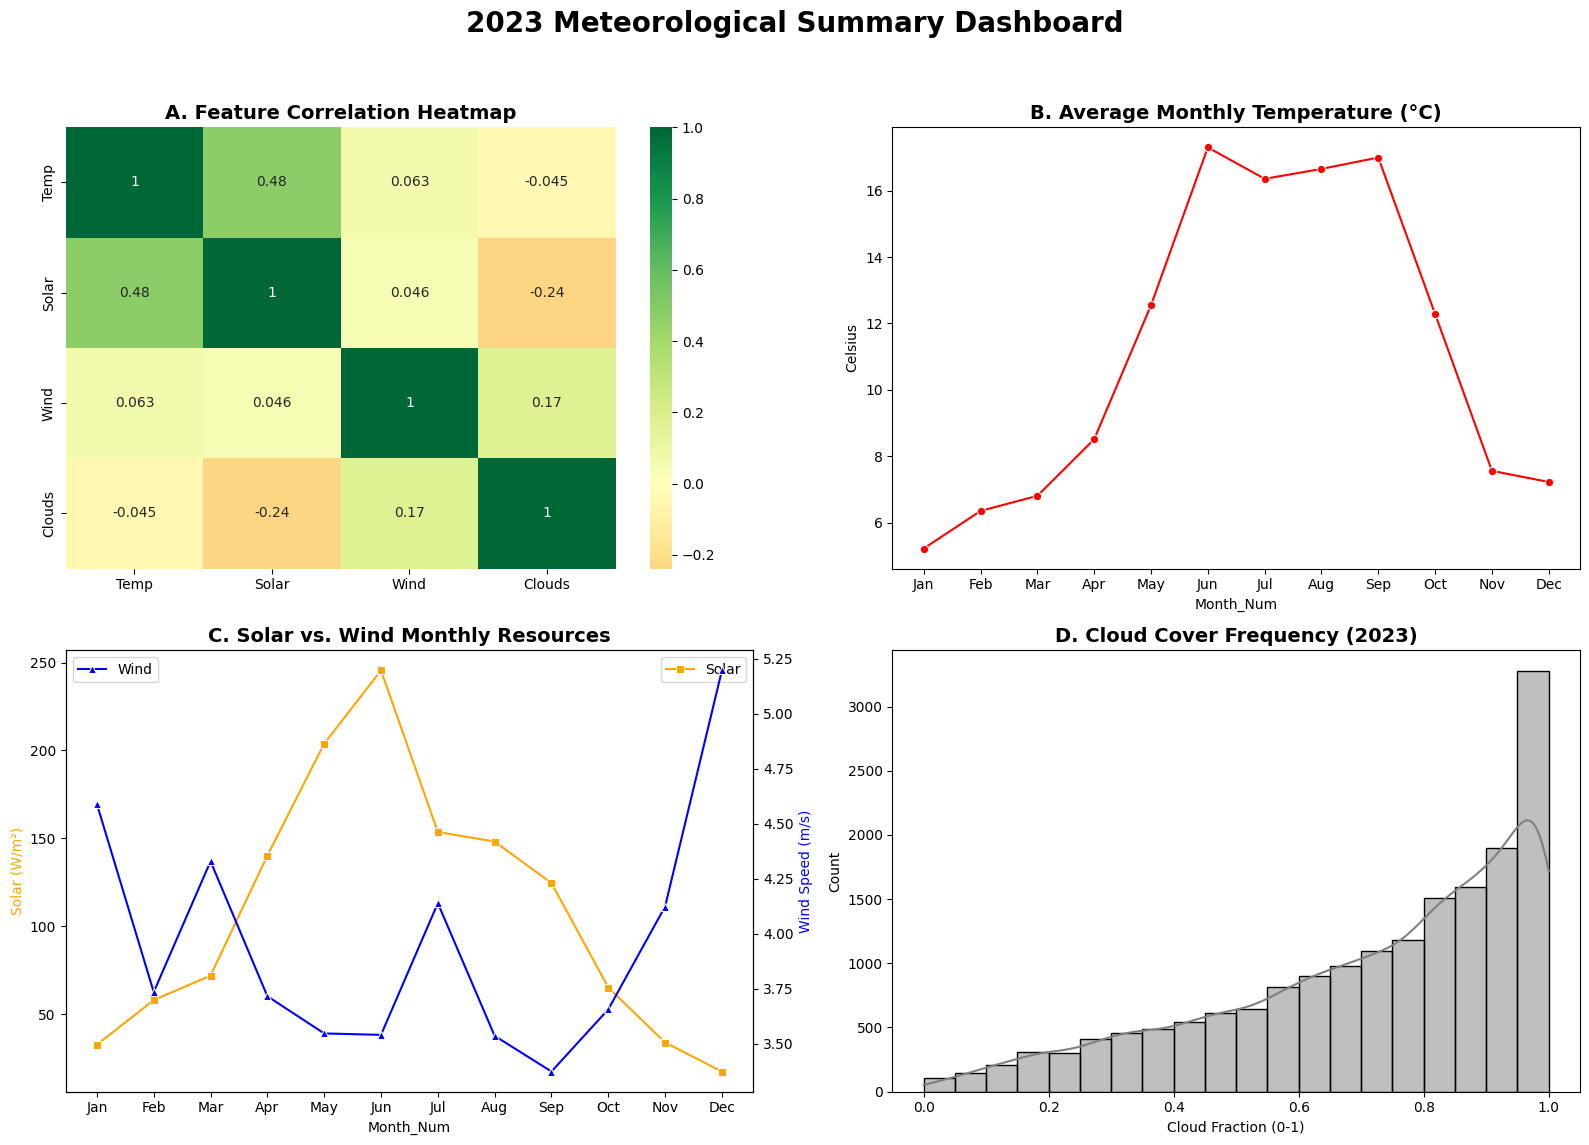

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Prepare 2023 Monthly Data for Normal Plotting
df_2023['timestamp_utc'] = pd.to_datetime(df_2023['timestamp_utc'])
df_2023['Month_Num'] = df_2023['timestamp_utc'].dt.month
month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

monthly_df = df_2023.groupby('Month_Num').agg({
    'ssrd_uk': 'mean',
    'ws10_uk': 'mean',
    't2m_uk': 'mean'
}).reset_index()
monthly_df['Month_Name'] = monthly_df['Month_Num'].map(month_map)

# 2. Define Correlation Matrix
corr_cols = {'t2m_uk': 'Temp', 'ssrd_uk': 'Solar', 'ws10_uk': 'Wind', 'tcc_uk': 'Clouds'}
df_corr = df_2023[list(corr_cols.keys())].rename(columns=corr_cols).corr()

# 3. Create Simplified Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('2023 Meteorological Summary Dashboard', fontsize=20, fontweight='bold')

# A. Correlation Heatmap (Easy interaction view)
sns.heatmap(df_corr, annot=True, cmap='RdYlGn', center=0, ax=axes[0,0])
axes[0,0].set_title('A. Feature Correlation Heatmap', fontsize=14, fontweight='bold')

# B. Monthly Temperature Trend (Normal Plot)
sns.lineplot(data=monthly_df, x='Month_Num', y=monthly_df['t2m_uk']-273.15, marker='o', color='red', ax=axes[0,1])
axes[0,1].set_xticks(range(1, 13))
axes[0,1].set_xticklabels(month_map.values())
axes[0,1].set_title('B. Average Monthly Temperature (°C)', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Celsius')

# C. Solar vs Wind Complementarity (Normal Overlaid Plot)
ax_c_twin = axes[1,0].twinx()
sns.lineplot(data=monthly_df, x='Month_Num', y='ssrd_uk', color='orange', marker='s', label='Solar', ax=axes[1,0])
sns.lineplot(data=monthly_df, x='Month_Num', y='ws10_uk', color='blue', marker='^', label='Wind', ax=ax_c_twin)
axes[1,0].set_xticks(range(1, 13))
axes[1,0].set_xticklabels(month_map.values())
axes[1,0].set_title('C. Solar vs. Wind Monthly Resources', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Solar (W/m²)', color='orange')
ax_c_twin.set_ylabel('Wind Speed (m/s)', color='blue')

# D. Cloud Cover Distribution (Normal Histogram)
sns.histplot(df_2023['tcc_uk'], bins=20, kde=True, color='grey', ax=axes[1,1])
axes[1,1].set_title('D. Cloud Cover Frequency (2023)', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Cloud Fraction (0-1)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### **2024 Advanced EDA: Seasonality and Regional Variations**

With the full 2024 dataset, we can move beyond simple line charts to look at feature interactions. We will examine:
1. **Renewable Complementarity**: How solar and wind power potential balance each other across months.
2. **Regional Thermal Profiles**: Temperature distributions across UK regions.
3. **Cloud-Solar Interaction**: The relationship between cloud cover and solar radiation intensity.

--- Step 1: Resolving 2024 file URLs ---


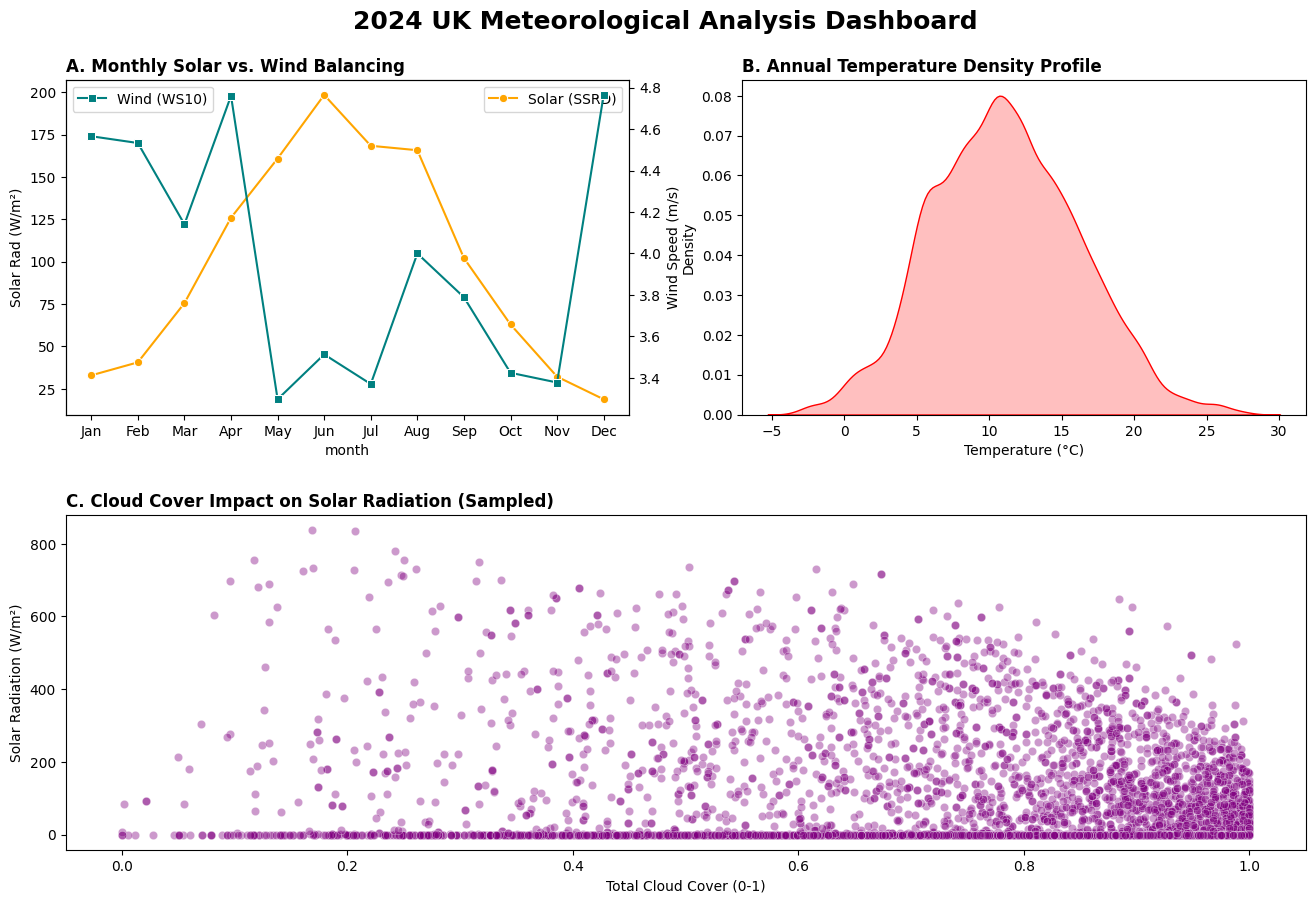

In [28]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Manually resolve 2024 file URLs to bypass the 'hf://' protocol bug
repo_id = "gridsight-team/gridsight-silver"
subfolder = "silver_met_office_nwp"
storage_options = {"token": token}

print("--- Step 1: Resolving 2024 file URLs ---")
try:
    file_urls_2024 = resolve_hf_urls(repo_id, subfolder, token, years=["2024"])
except Exception as e:
    print(f"Error resolving URLs: {e}")
    raise e

# 2. Load and process 2024 data
try:
    lazy_df = pl.scan_parquet(file_urls_2024, storage_options=storage_options)
    df_2024 = (
        lazy_df
        .with_columns(pl.col("timestamp_utc").cast(pl.String))
        .collect()
        .to_pandas()
    )
except Exception as e:
    print(f"Error loading 2024 parquet data: {e}")
    raise e

df_2024['timestamp_utc'] = pd.to_datetime(df_2024['timestamp_utc'])
df_2024['month'] = df_2024['timestamp_utc'].dt.month

# 3. Prepare monthly aggregates
monthly_stats = df_2024.groupby('month').agg({
    'ssrd_uk': 'mean',
    'ws10_uk': 'mean',
    't2m_uk': 'mean'
}).reset_index()

# 4. Set up the visualization
fig = plt.figure(figsize=(16, 10))
grid = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)
fig.suptitle('2024 UK Meteorological Analysis Dashboard', fontsize=18, fontweight='bold', y=0.95)

# Solar vs Wind Complementarity
ax1 = fig.add_subplot(grid[0, 0])
ax1_twin = ax1.twinx()
sns.lineplot(data=monthly_stats, x='month', y='ssrd_uk', color='orange', marker='o', label='Solar (SSRD)', ax=ax1)
sns.lineplot(data=monthly_stats, x='month', y='ws10_uk', color='teal', marker='s', label='Wind (WS10)', ax=ax1_twin)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax1.set_title('A. Monthly Solar vs. Wind Balancing', loc='left', fontweight='bold')
ax1.set_ylabel('Solar Rad (W/m²)')
ax1_twin.set_ylabel('Wind Speed (m/s)')

# Temperature Distribution Density
ax2 = fig.add_subplot(grid[0, 1])
sns.kdeplot(x=df_2024['t2m_uk']-273.15, fill=True, color='red', ax=ax2)
ax2.set_title('B. Annual Temperature Density Profile', loc='left', fontweight='bold')
ax2.set_xlabel('Temperature (°C)')

# Cloud Cover vs Solar Radiation (Sampled for speed)
ax3 = fig.add_subplot(grid[1, :])
# Guarded sample size
sample_df = df_2024.sample(min(len(df_2024), 5000))
sns.scatterplot(data=sample_df, x='tcc_uk', y='ssrd_uk', alpha=0.4, color='purple', ax=ax3)
ax3.set_title('C. Cloud Cover Impact on Solar Radiation (Sampled)', loc='left', fontweight='bold')
ax3.set_xlabel('Total Cloud Cover (0-1)')
ax3.set_ylabel('Solar Radiation (W/m²)')

plt.show()


### **2025 Met Office NWP Data: Daily Trends of Key Meteorological Variables**

This section visualizes the daily average trends for temperature, solar radiation, and wind speed throughout 2025. This helps in understanding the seasonal variations and overall patterns of these critical weather parameters.

In [16]:
import polars as pl
import pandas as pd

repo_id = "gridsight-team/gridsight-silver"
subfolder = "silver_met_office_nwp"

print("--- Step 1: Resolving individual file URLs for 2025 ---")
try:
    file_urls = resolve_hf_urls(repo_id, subfolder, token, years=["2025"])
except Exception as e:
    print(f"Error resolving 2025 URLs: {e}")
    raise e

if not file_urls:
    print("❌ No 2025 parquet files were found. Please verify the dataset contains 2025 data.")
else:
    print(f"Found {len(file_urls)} files. Scanning data...")

    storage_options = {"token": token}

    try:
        # 2. Scan the specific list of URLs
        lazy_df = pl.scan_parquet(file_urls, storage_options=storage_options)

        print("--- Step 2: Filtering and Collecting ---")
        # Cast timestamp to string for safety and perform collection
        df_2025 = (
            lazy_df
            .with_columns(pl.col("timestamp_utc").cast(pl.String))
            .collect()
            .to_pandas()
        )
    except Exception as e:
        print(f"Error loading 2025 data: {e}")
        raise e

    print("✅ Successfully loaded 2025 data!")

    # =====================================================================
    # STEP 4: ANALYZE RESULTS
    # =====================================================================
    print("\n=== 2025 Dataset Shape (Rows, Columns) ===")
    print(df_2025.shape)
    print("\n=== First 5 Rows Preview ===")
    print(df_2025.head())


--- Step 1: Resolving individual file URLs for 2025 ---
Found 1 files. Scanning data...
--- Step 2: Filtering and Collecting ---
✅ Successfully loaded 2025 data!

=== 2025 Dataset Shape (Rows, Columns) ===
(7, 9)

=== First 5 Rows Preview ===
                      timestamp_utc  ssrd_uk  tcc_uk    lcc_uk      t2m_uk  \
0  2025-01-01 00:00:00.000000+00:00      0.0  0.9625  0.945156  283.202332   
1  2025-01-01 00:30:00.000000+00:00      0.0  0.9625  0.945156  283.202332   
2  2025-01-01 01:00:00.000000+00:00      0.0  1.0000  0.995313  283.141418   
3  2025-01-01 01:30:00.000000+00:00      0.0  1.0000  0.995313  283.141418   
4  2025-01-01 02:00:00.000000+00:00      0.0  0.9550  0.791094  283.031250   

    ws10_uk                 init_time  nwp_age_h data_quality_flag  
0  8.985625 2024-12-31 12:00:00+00:00       12.0                ok  
1  8.985625 2024-12-31 12:00:00+00:00       12.0                ok  
2  9.128125 2024-12-31 12:00:00+00:00       13.0                ok  
3  9.128125 

=== 1. 2025 Statistical Summary ===


statistic,t2m_uk,ssrd_uk,ws10_uk,tcc_uk,lcc_uk
str,f64,f64,f64,f64,f64
"""count""",7.0,7.0,7.0,7.0,7.0
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",283.100128,0.0,9.136161,0.976429,0.905279
"""std""",0.096652,0.0,0.116569,0.022261,0.087994
"""min""",282.950928,0.0,8.985625,0.955,0.791094
"""25%""",283.03125,0.0,9.128125,0.9625,0.873828
"""50%""",283.141418,0.0,9.128125,0.9625,0.945156
"""75%""",283.202332,0.0,9.22125,1.0,0.995313
"""max""",283.202332,0.0,9.283125,1.0,0.995313



=== 2. Missing Data Audit (2025) ===
shape: (1, 9)
┌───────────────┬─────────┬────────┬────────┬───┬─────────┬───────────┬───────────┬────────────────┐
│ timestamp_utc ┆ ssrd_uk ┆ tcc_uk ┆ lcc_uk ┆ … ┆ ws10_uk ┆ init_time ┆ nwp_age_h ┆ data_quality_f │
│ ---           ┆ ---     ┆ ---    ┆ ---    ┆   ┆ ---     ┆ ---       ┆ ---       ┆ lag            │
│ u32           ┆ u32     ┆ u32    ┆ u32    ┆   ┆ u32     ┆ u32       ┆ u32       ┆ ---            │
│               ┆         ┆        ┆        ┆   ┆         ┆           ┆           ┆ u32            │
╞═══════════════╪═════════╪════════╪════════╪═══╪═════════╪═══════════╪═══════════╪════════════════╡
│ 0             ┆ 0       ┆ 0      ┆ 0      ┆ … ┆ 0       ┆ 0         ┆ 0         ┆ 0              │
└───────────────┴─────────┴────────┴────────┴───┴─────────┴───────────┴───────────┴────────────────┘


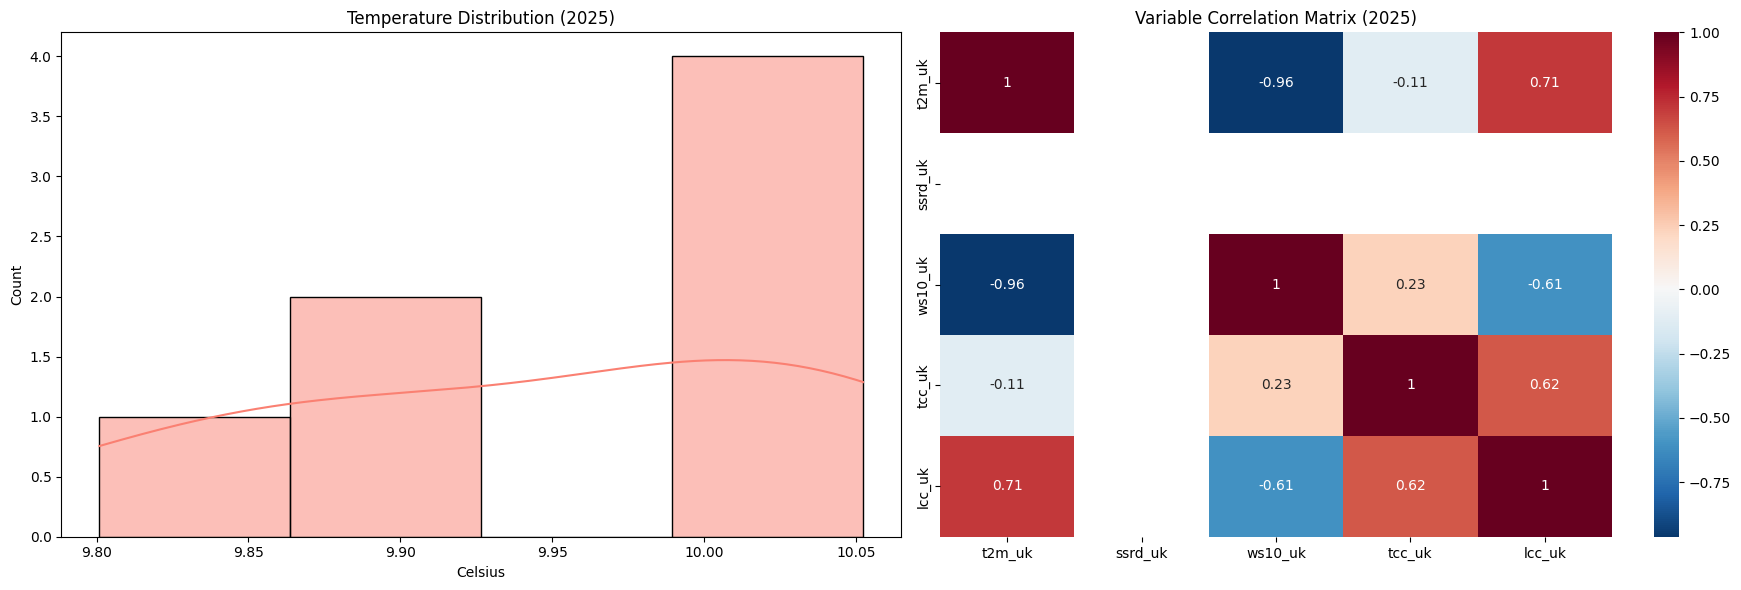

In [20]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# Convert the pandas df_2025 to Polars for high-performance analysis
df_2025_pl = pl.from_pandas(df_2025)

print("=== 1. 2025 Statistical Summary ===")
# Focus on the key meteorological metrics
metrics = ['t2m_uk', 'ssrd_uk', 'ws10_uk', 'tcc_uk', 'lcc_uk']
display(df_2025_pl.select(metrics).describe())

print("\n=== 2. Missing Data Audit (2025) ===")
print(df_2025_pl.null_count())

# Visualizing distributions and correlations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Distribution of Temperature
sns.histplot(df_2025['t2m_uk'] - 273.15, kde=True, ax=ax1, color='salmon')
ax1.set_title('Temperature Distribution (2025)')
ax1.set_xlabel('Celsius')

# Correlation Matrix
corr = df_2025[metrics].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, ax=ax2)
ax2.set_title('Variable Correlation Matrix (2025)')

plt.tight_layout()
plt.show()

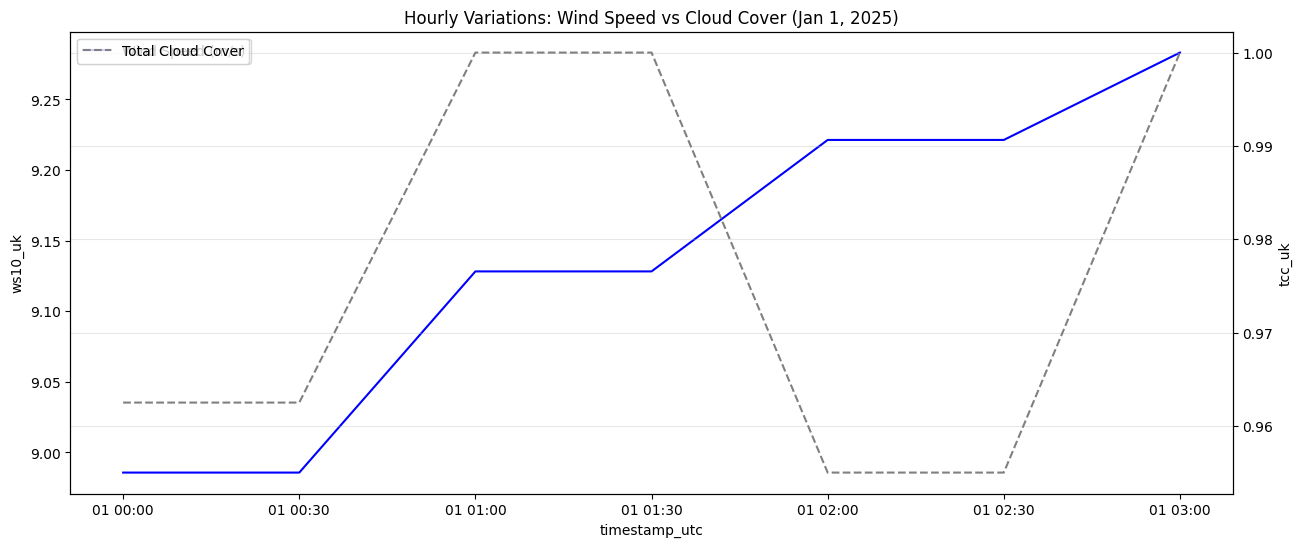

In [22]:
# 1. Hourly Trend Analysis for 2025 start
plt.figure(figsize=(15, 6))
sns.lineplot(data=df_2025, x='timestamp_utc', y='ws10_uk', label='Wind Speed (m/s)', color='blue')
ax2 = plt.twinx()
sns.lineplot(data=df_2025, x='timestamp_utc', y='tcc_uk', label='Total Cloud Cover', color='grey', ax=ax2, linestyle='--')
plt.title('Hourly Variations: Wind Speed vs Cloud Cover (Jan 1, 2025)')
plt.grid(True, alpha=0.3)
plt.show()



⠀ Resolving file paths for 2023-2024 data...
⠀ Scanning 24 parquet partitions...
-> Aggregating monthly metrics...
⠀ Dashboarding results for 2023 & 2024...


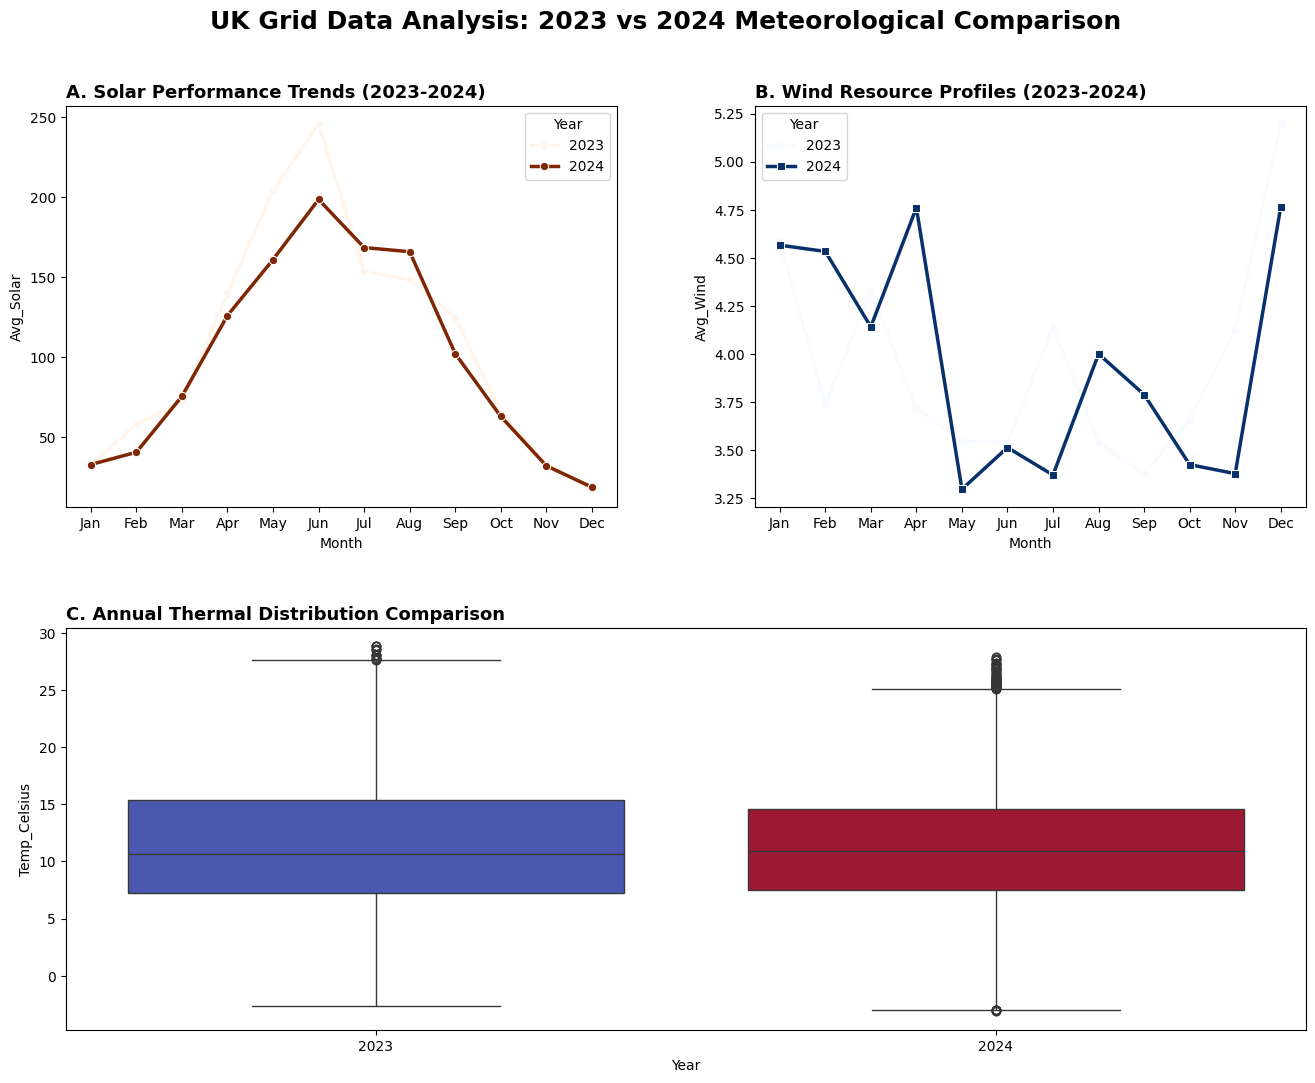

In [37]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETUP AND CLOUD PATH RESOLUTION
# ==========================================
repo_id = "gridsight-team/gridsight-silver"
subfolder = "silver_met_office_nwp"
storage_options = {"token": token}

print("⠀ Resolving file paths for 2023-2024 data...")
try:
    file_urls = resolve_hf_urls(repo_id, subfolder, token, years=["2023", "2024"])
except Exception as e:
    print(f"Error resolving multi-year URLs: {e}")
    raise e

print(f"⠀ Scanning {len(file_urls)} parquet partitions...")

# ==========================================
# 2. DATA PROCESSING PIPELINE
# ==========================================
try:
    df_selected_years = (
        pl.scan_parquet(file_urls, storage_options=storage_options)
        .with_columns([
            pl.col("timestamp_utc").dt.year().alias("Year"),
            pl.col("timestamp_utc").dt.month().alias("Month"),
            (pl.col("t2m_uk") - 273.15).alias("Temp_Celsius")
        ])
        .filter(pl.col("Year").is_in([2023, 2024]))
        .collect()
    )
except Exception as e:
    print(f"Error scanning multi-year parquets: {e}")
    raise e

print("-> Aggregating monthly metrics...")
df_monthly = (
    df_selected_years
    .group_by(["Year", "Month"])
    .agg([
        pl.col("Temp_Celsius").mean().alias("Avg_Temp"),
        pl.col("ssrd_uk").mean().alias("Avg_Solar"),
        pl.col("ws10_uk").mean().alias("Avg_Wind")
    ])
    .sort(["Year", "Month"])
    .to_pandas()
)

# Sample for distribution plotting
df_sample = df_selected_years.sample(n=min(40000, len(df_selected_years))).to_pandas()

print("⠀ Dashboarding results for 2023 & 2024...")

# ==========================================
# 3. VISUALIZATION
# ==========================================
fig = plt.figure(figsize=(16, 12))
grid = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)
fig.suptitle("UK Grid Data Analysis: 2023 vs 2024 Meteorological Comparison", fontsize=18, fontweight='bold', y=0.96)
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Solar Comparison
ax1 = fig.add_subplot(grid[0, 0])
sns.lineplot(data=df_monthly, x='Month', y='Avg_Solar', hue='Year', marker='o', palette='Oranges', linewidth=2.5, ax=ax1)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_labels)
ax1.set_title('A. Solar Performance Trends (2023-2024)', fontsize=13, fontweight='bold', loc='left')

# Wind Comparison
ax2 = fig.add_subplot(grid[0, 1])
sns.lineplot(data=df_monthly, x='Month', y='Avg_Wind', hue='Year', marker='s', palette='Blues', linewidth=2.5, ax=ax2)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_labels)
ax2.set_title('B. Wind Resource Profiles (2023-2024)', fontsize=13, fontweight='bold', loc='left')

# Temperature Distribution
ax3 = fig.add_subplot(grid[1, :])
sns.boxplot(data=df_sample, x='Year', y='Temp_Celsius', hue='Year', palette='coolwarm', ax=ax3, legend=False)
ax3.set_title('C. Annual Thermal Distribution Comparison', fontsize=13, fontweight='bold', loc='left')

plt.show()


### **2023 Deep-Dive EDA: Individual Year Analysis**
This section focuses exclusively on the meteorological patterns of 2023, analyzing the relationship between temperature, solar radiation, and wind speed.

--- 2023 Basic Stats ---
       Temp_Celsius       ssrd_uk       ws10_uk
count  17472.000000  17475.000000  17472.000000
mean      11.169543    108.012131      3.963140
std        5.564761    171.564209      1.623975
min       -2.644043      0.000000      0.904375
25%        7.209717      0.000000      2.699219
50%       10.614151      2.928828      3.695938
75%       15.385109    164.590149      4.917031
max       28.829071    892.574829     11.095625


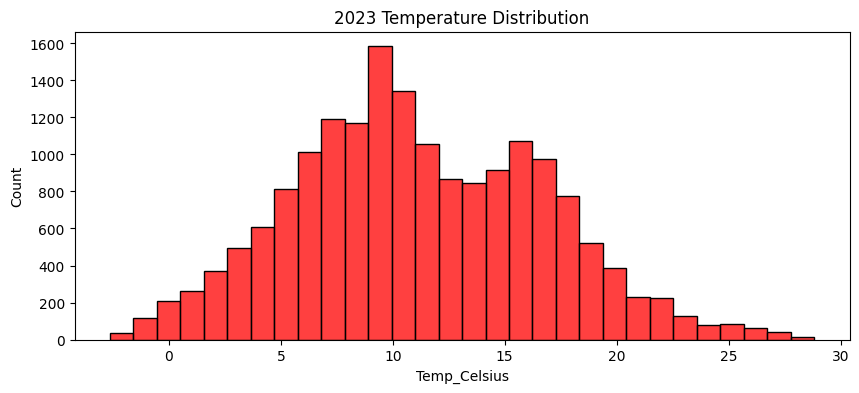

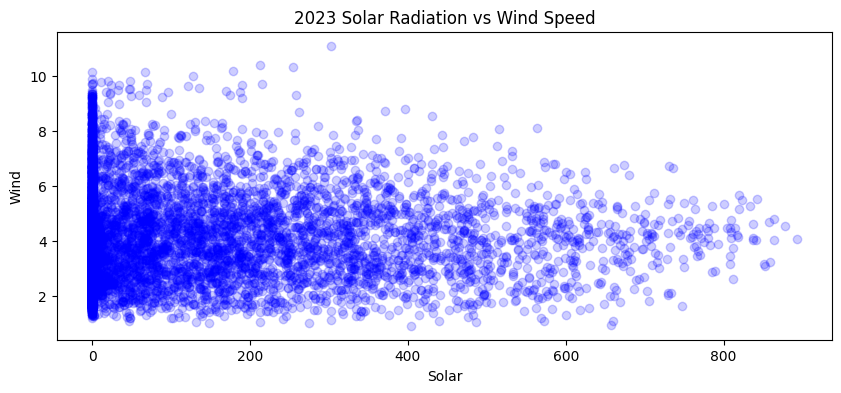

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic 2023 Analysis
df_2023 = df_selected_years.filter(pl.col('Year') == 2023).to_pandas()

print("--- 2023 Basic Stats ---")
print(df_2023[['Temp_Celsius', 'ssrd_uk', 'ws10_uk']].describe())

# Simple Plot 1: Temperature Histogram
plt.figure(figsize=(10, 4))
sns.histplot(df_2023['Temp_Celsius'], color='red', bins=30)
plt.title('2023 Temperature Distribution')
plt.show()

# Simple Plot 2: Solar vs Wind Scatter
plt.figure(figsize=(10, 4))
plt.scatter(df_2023['ssrd_uk'], df_2023['ws10_uk'], alpha=0.1, color='blue')
plt.title('2023 Solar Radiation vs Wind Speed')
plt.xlabel('Solar')
plt.ylabel('Wind')
plt.show()

### **2024 Deep-Dive EDA: Individual Year Analysis**
Now analyzing the 2024 dataset independently to identify its specific climatic profile and resource availability.

--- 2024 Basic Stats ---
       Temp_Celsius       ssrd_uk       ws10_uk
count  17472.000000  17478.000000  17472.000000
mean      11.125734     98.821938      3.959328
std        5.055526    155.052170      1.695193
min       -3.118652      0.000000      0.518750
25%        7.533882      0.000000      2.749063
50%       10.953476      2.484062      3.655625
75%       14.560089    151.670319      4.852500
max       27.910309    837.620483     12.347500


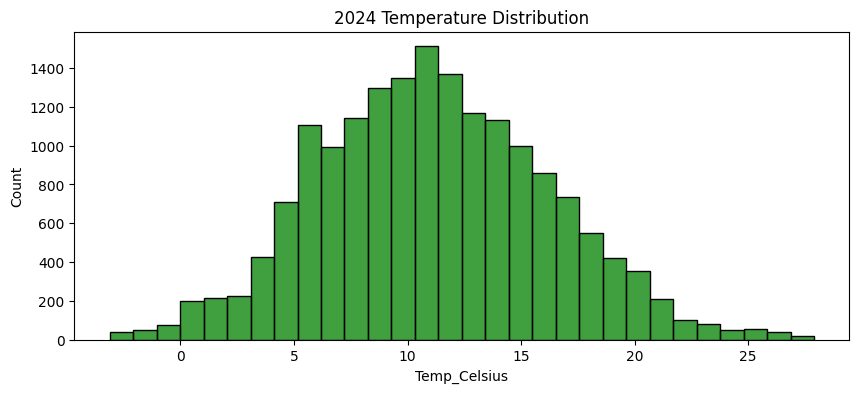

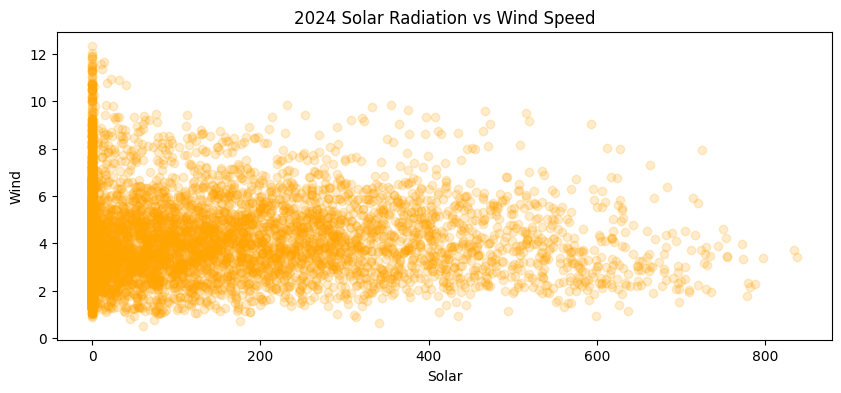

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic 2024 Analysis
df_2024 = df_selected_years.filter(pl.col('Year') == 2024).to_pandas()

print("--- 2024 Basic Stats ---")
print(df_2024[['Temp_Celsius', 'ssrd_uk', 'ws10_uk']].describe())

# Simple Plot 1: Temperature Histogram
plt.figure(figsize=(10, 4))
sns.histplot(df_2024['Temp_Celsius'], color='green', bins=30)
plt.title('2024 Temperature Distribution')
plt.show()

# Simple Plot 2: Solar vs Wind Scatter
plt.figure(figsize=(10, 4))
plt.scatter(df_2024['ssrd_uk'], df_2024['ws10_uk'], alpha=0.1, color='orange')
plt.title('2024 Solar Radiation vs Wind Speed')
plt.xlabel('Solar')
plt.ylabel('Wind')
plt.show()